In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from pyprojroot import here
import sys
import config
from data_utils import best_players_plots, table_simulation, expected_stats_vs_actuals, sort_data, colors_config

In [3]:
data = pd.read_parquet(config.TIDY_DATA_PATH)

In [4]:
data = sort_data(data)
data.head()

,position,team_name,match_id,web_name,second_name,first_name,status,player_code,touches_opposition_box,gw,team_code,id,selected_by_percent,ep_this,goals_conceded,threat,expected_assists,fouls_committed,now_cost,xgot,chances_created,penalties_scored,tackles_won,value_season,ict_index,clearances,accurate_passes_percent,blocks,successful_dribbles_percent,xa,creativity,tackles_won_percent,xgot_faced,value_form,selected_rank,influence,penalties_order,successful_dribbles,gk_accurate_long_balls,transfers_in_event,finish_min,accurate_crosses,interceptions,tackles,sweeper_actions,aerial_duels_won_percent,was_fouled,corners_and_indirect_freekicks_order,headed_clearances,bonus,total_points,offsides,duels_lost,form,event_points,accurate_crosses_percent,ground_duels_won,ground_duels_won_percent,start_min,gk_accurate_passes,team_strength,transfers_out,cost_change_event,saves,aerial_duels_won,accurate_passes,goals_prevented,dreamteam_count,bps,expected_goals_conceded,assists,ep_next,transfers_out_event,penalties_missed,duels_won,final_third_passes,dribbled_past,now_cost_rank,recoveries,minutes_played,touches,expected_goal_involvements,chance_of_playing_next_round,cost_change_start,direct_freekicks_order,goals,transfers_in,team_goals_conceded,xg,accurate_long_balls_percent,shots_on_target,big_chances_missed,high_claim,accurate_long_balls,total_shots,chance_of_playing_this_round,expected_goals,season_id,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90
0,MID,Brighton,24-25-prem-everton-vs-brighton-&-hove-albion,Milner,Milner,James,a,15157,2,1,36,134,0.1,1.6,0,4,0.11,1,5.0,0.0,3,0,2,0.4,7.0,0,85,2,0,0.11,43.8,50,0.0,0.4,471,22.4,6,0,0,513,82,2,0,4,0,0,0,1,0,0,2,0,2,2.0,2,29,4,80,0,0,3,421,0,0,0,28,0.0,0,10,0.45,0,1.6,421,0,4,2,0,172,0,82,48,0.11,0,0,7,0,513,0,0.0,33,0,0,0,1,0,0,0.0,2425,0.0,0.120732,0.120732,0.493902
1,MID,Brighton,24-25-prem-brighton-&-hove-albion-vs-mancheste...,Milner,Milner,James,a,15157,2,2,36,134,0.1,2.0,0,12,0.15,1,5.0,0.0,1,0,0,0.8,10.7,2,73,0,100,0.04,66.2,0,0.0,0.4,448,28.6,6,1,0,1189,73,1,1,1,0,0,1,1,0,0,4,0,1,2.0,2,100,3,75,0,0,3,1548,0,0,0,22,0.0,0,22,1.77,0,1.0,635,0,3,6,0,177,2,73,42,0.31,0,0,7,0,2267,1,0.16,0,1,0,0,0,2,0,0.16,2425,0.19726,0.049315,0.382192,2.182192
2,MID,Brighton,24-25-prem-arsenal-vs-brighton-&-hove-albion,Milner,Milner,James,d,15157,0,3,36,134,0.1,0.7,0,12,0.15,1,5.0,0.0,0,0,0,1.0,10.7,0,100,0,0,0.0,66.3,0,0.0,0.3,461,28.6,6,0,0,472,17,0,1,0,0,0,0,1,0,0,5,0,1,1.7,1,0,0,0,0,0,3,4535,0,0,0,2,0.0,0,24,1.98,0,1.7,1998,0,0,0,0,185,0,17,4,0.31,75,0,7,0,4199,0,0.0,0,0,0,0,0,0,0,0.16,2425,0.0,0.0,1.641176,10.482353
3,MID,Brighton,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,Milner,Milner,James,a,15157,0,38,36,134,0.0,0.0,0,12,0.15,0,5.0,0.0,0,0,0,1.2,10.7,0,0,0,0,0.0,66.3,0,0.0,0.0,586,28.6,6,0,0,0,93,0,0,0,0,0,0,8,0,0,6,0,0,0.2,1,0,0,0,93,0,3,10991,0,0,0,0,0.0,0,27,1.98,0,0.0,0,0,0,1,0,192,0,1,1,0.31,100,0,7,0,5014,0,0.0,0,0,0,0,0,0,0,0.16,2425,0.0,0.0,27.9,178.2
4,MID,Brighton,25-26-prem-brighton-hove-albion-vs-fulham,Milner,Milner,James,a,15157,0,1,36,170,0.1,0.0,0,0,0.0,0,4.9,0.0,0,0,0,3.1,0.0,0,0,0,0,0.0,0.1,0,0.0,0.0,467,0.0,1,0,0,113,90,0,0,0,0,0,0,5,0,0,1,0,0,0.0,1,0,0,0,0,0,3,20304,0,0,0,1,0.0,0,3,0.24,0,-0.5,497,0,0,0,0,283,0,2,1,0.0,100,-1,7,0,14413,1,0.0,0,0,0,0,0,0,0,0.0,2526,0.0,0.0,0.0,10.8


In [5]:
data.describe()

,player_code,touches_opposition_box,gw,team_code,id,selected_by_percent,ep_this,goals_conceded,threat,expected_assists,fouls_committed,now_cost,xgot,chances_created,penalties_scored,tackles_won,value_season,ict_index,clearances,accurate_passes_percent,blocks,successful_dribbles_percent,xa,creativity,tackles_won_percent,xgot_faced,value_form,selected_rank,influence,penalties_order,successful_dribbles,gk_accurate_long_balls,transfers_in_event,finish_min,accurate_crosses,interceptions,tackles,sweeper_actions,aerial_duels_won_percent,was_fouled,corners_and_indirect_freekicks_order,headed_clearances,bonus,total_points,offsides,duels_lost,form,event_points,accurate_crosses_percent,ground_duels_won,ground_duels_won_percent,start_min,gk_accurate_passes,team_strength,transfers_out,cost_change_event,saves,aerial_duels_won,accurate_passes,goals_prevented,dreamteam_count,bps,expected_goals_conceded,assists,ep_next,transfers_out_event,penalties_missed,duels_won,final_third_passes,dribbled_past,now_cost_rank,recoveries,minutes_played,touches,expected_goal_involvements,chance_of_playing_next_round,cost_change_start,direct_freekicks_order,goals,transfers_in,team_goals_conceded,xg,accurate_long_balls_percent,shots_on_target,big_chances_missed,high_claim,accurate_long_balls,total_shots,chance_of_playing_this_round,expected_goals,season_id,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90
count,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.0,22298.000000,22298.0,22298.0,22298.0,22298.0
mean,303363.702305,1.69948,16.925644,28.629115,352.276168,4.15157,2.500345,0.089918,79.183559,0.535047,0.707552,5.350081,0.094487,0.621939,0.006593,0.405642,6.872818,29.137178,1.570769,43.920127,0.229886,12.142838,0.062085,87.113571,17.419903,0.088824,0.463459,249.625841,125.306018,5.588977,0.463808,0.351601,22382.509956,79.057315,0.274599,0.518881,1.059243,0.037851,17.724146,0.683425,7.17885,0.811732,1.826307,22.736299,0.006054,3.169746,2.504274,2.748722,5.667235,2.253162,24.44134,12.025518,1.399901,3.217419,325713.183021,-0.008207,0.185712,0.924836,24.081622,0.002,0.301686,96.808279,8.504952,0.066374,2.453565,18432.695533,0.00157,3.177998,3.446587,0.467845,269.21271,3.074715,63.713562,41.1101,1.362053,52.52489,-0.778276,6.434882,0.092923,355450.175442,1.127231,0.09497,18.343349,0.291685,0.097094,0.052067,1.327115,0.802045,52.483407,0.827095,2473.606646,0.193854,0.113518,3.792906,24.029312
std,163954.569684,2.276363,10.051058,27.761674,208.142294,8.412178,2.073324,0.457,159.363176,1.037059,0.957592,1.276647,0.259046,1.002686,0.086292,0.859977,5.751317,45.060485,2.227908,41.655871,0.56404,29.303634,0.11863,154.546778,34.703313,0.414561,0.339831,187.390009,185.705496,1.229432,0.906176,1.601529,68238.742451,28.472529,0.689481,0.863115,1.383154,0.255544,33.279514,0.973301,2.007976,1.429098,4.162324,33.390015,0.09284,2.78595,1.919569,2.995423,19.0826,2.215443,32.465054,27.383017,5.718427,0.761568,839331.779579,0.325164,0.854326,1.40339,20.142622,0.195018,0.841302,137.251525,11.79646,0.264488,2.064472,56576.194229,0.040706,2.729534,3.651677,0.802836,193.360665,2.736008,32.546491,26.455476,2.702427,49.496432,2.13969,1.573397,0.322669,937943.471492,1.136984,0.208463,32.124153,0.619345,0.341136,0.321631,2.015903,1.194917,49.354199,1.92403,50.465626,1.219829,0.57963,17.159403,105

In [6]:
data.shape

(22298, 102)

In [7]:
data[~data['match_id'].str.contains('prem', na=False)].sample(10)

,position,team_name,match_id,web_name,second_name,first_name,status,player_code,touches_opposition_box,gw,team_code,id,selected_by_percent,ep_this,goals_conceded,threat,expected_assists,fouls_committed,now_cost,xgot,chances_created,penalties_scored,tackles_won,value_season,ict_index,clearances,accurate_passes_percent,blocks,successful_dribbles_percent,xa,creativity,tackles_won_percent,xgot_faced,value_form,selected_rank,influence,penalties_order,successful_dribbles,gk_accurate_long_balls,transfers_in_event,finish_min,accurate_crosses,interceptions,tackles,sweeper_actions,aerial_duels_won_percent,was_fouled,corners_and_indirect_freekicks_order,headed_clearances,bonus,total_points,offsides,duels_lost,form,event_points,accurate_crosses_percent,ground_duels_won,ground_duels_won_percent,start_min,gk_accurate_passes,team_strength,transfers_out,cost_change_event,saves,aerial_duels_won,accurate_passes,goals_prevented,dreamteam_count,bps,expected_goals_conceded,assists,ep_next,transfers_out_event,penalties_missed,duels_won,final_third_passes,dribbled_past,now_cost_rank,recoveries,minutes_played,touches,expected_goal_involvements,chance_of_playing_next_round,cost_change_start,direct_freekicks_order,goals,transfers_in,team_goals_conceded,xg,accurate_long_balls_percent,shots_on_target,big_chances_missed,high_claim,accurate_long_balls,total_shots,chance_of_playing_this_round,expected_goals,season_id,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90
21010,MID,Brighton,25-26-efl-cup-brighton-hove-albion-vs-arsenal,Watson,Watson,Tom,a,549074,2,9,36,172,0.0,0.2,0,7,0.01,0,4.9,0.0,2,0,0,0.2,1.4,0,0,0,0,0.11,1.3,0,0.0,0.0,627,5.6,6,1,0,36,90,0,0,0,0,0,0,8,0,0,1,0,3,0.2,1,0,1,0,67,0,3,86,0,0,0,8,0.0,0,7,0.67,0,0.7,43,0,1,1,2,347,2,22,15,0.05,100,-1,7,0,50,1,0.0,0,0,0,0,0,0,100,0.04,2526,0.0,0.45,0.204545,2.740909
13695,MID,Newcastle,25-26-champions-league-newcastle-united-vs-qar...,Tonali,Tonali,Sandro,a,432422,0,27,4,491,1.0,1.3,0,2,0.18,2,5.3,0.0,1,0,0,11.9,3.8,0,0,0,0,0.2,26.3,0,0.0,0.3,189,10.0,6,0,0,4715,90,1,2,2,0,0,2,1,0,0,2,0,4,1.8,2,0,4,0,0,0,3,1413,0,0,0,64,0.0,0,15,1.35,0,1.8,1358,0,4,5,0,197,2,90,89,0.18,100,-2,1,0,4789,1,0.04,0,0,0,0,1,1,100,0.0,2526,0.04,0.2,0.18,1.35
10079,MID,Nott'm Forest,25-26-europa-league-nottingham-forest-vs-real-...,Gibbs-White,Gibbs-White,Morgan,a,222531,3,5,17,515,5.1,2.5,0,25,0.05,2,7.5,0.08,1,0,0,1.7,6.9,0,0,0,0,0.64,28.7,0,0.0,0.3,70,15.0,6,0,0,3971,95,1,0,0,0,0,1,8,0,0,2,0,5,2.0,2,0,1,0,0,0,3,73062,0,0,1,21,0.0,0,16,0.85,1,2.5,22793,0,2,2,0,24,1,90,37,0.13,0,0,7,0,55623,2,0.16,0,1,1,0,1,2,0,0.08,2526,0.16,0.64,0.13,0.85
22231,FWD,Brighton,25-26-efl-cup-brighton-hove-albion-vs-arsenal,Kostoulas,Kostoulas,Charalampos,a,647850,4,9,36,181,0.3,1.5,0,40,0.01,2,4.8,0.0,0,0,0,1.2,7.5,2,0,0,0,0.03,0.5,0,0.0,0.3,308,34.2,6,1,0,954,46,0,1,0,0,0,0,8,1,0,5,0,6,1.5,5,0,1,0,0,0,3,1366,0,0,2,9,0.0,0,29,0.43,0,2.0,477,0,3,0,1,380,1,45,23,0.28,0,-2,7,0,1539,0,0.21,0,0,0,0,0,1,0,0.27,2526,0.42,0.06,0.56,0.86
7329,MID,Arsenal,25-26-champions-league-arsenal-vs-inter,Rice,Rice,Declan,a,204480,2,23,3,21,32.1,7.0,0,10,0.47,1,7.4,0.0,1,0,0,17.0,8.3,1,0,0,0,0.05,54.5,0,0.0,0.8,9,18.4,6,0,0,291343,90,0,0,1,0,0,0,1,0,0,1,0,3,6.0,1,0,1,0,0,0,5,172444,0,0,1,16,0.0,0,18,0.71,0,7.0,162704,0,2,1,0,22,1,26,23,0.58,100,9,1,0,356371,1,0.0,0,0,0,0,0,0,100,0.11,2526,0.0,0.173077,2.007692,2.457692
12863,DEF,Crystal Palace,25-26-efl-cup-crystal-palace-vs-liverpool,Muñoz,Muñoz Mejía,Daniel,a,247348,2,9,31,256,16.7,4.7,0,4,0.02,3,5.8,0.0,0,0,0,10.3,1.9,4,0,0,0,0.02,3.8,0,0.0,0.8,23,11.6,6,0,0,124368,74,0,2,1,0,0,0,8,2,0,2,0,5,4.7,2,0,1,0,0,0,3,0,1,0,4,20,0.0,0,3,1.08,0,4.7,14232,0,5,6,1,108,3,74,44,0.02,0,3,7,0,0,0,0.0,0,0,0,0,1,0,0,0.0,2526,0.0,0.024324,0.024324,1.313514
2331,MID,Crystal Palace,25-26-conference-league-crystal-palace-vs-stra...,Hughes,Hughes,Will,d,108413,0,12,31,270,0.1,1.0,0,0,0.0,1,4.8,0.0,0,0,0,3.1,0.1,0,0,0,0,0.01,0.0,0,0.0,0.2,477,1.0,6,0,0,107,0,0,0,1,0,0,0,2,0,0,1,0,2,1.0,1,0,1,0,0,0,

In [8]:
data = data[data['match_id'].str.contains('prem', na=False, case=False)]


In [9]:
match_id_team_name_map = {'arsenal':'Arsenal','aston-villa':'Aston Villa','afc-bournemouth':'Bournemouth','brentford':'Brentford','brighton-&-hove-albion':'Brighton','burnley':'Burnley','chelsea':'Chelsea','crystal-palace':'Crystal Palace','everton':'Everton','fulham':'Fulham','ipswich-town':'Ipswich','leeds-united':'Leeds','leicester-city':'Leicester','liverpool':'Liverpool','manchester-city':'Man City','manchester-united':'Man Utd','newcastle-united':'Newcastle','nottingham-forest':"Nott'm Forest",'southampton':'Southampton','tottenham-hotspur':'Spurs','sunderland':'Sunderland','west-ham-united':'West Ham','wolverhampton-wanderers':'Wolves'}
data['was_home'] = pd.to_numeric(data['team_name'] == data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1].map(match_id_team_name_map))

In [10]:
raw_home = data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1]
raw_home[~raw_home.isin(match_id_team_name_map.keys())].unique()[0]

'brighton-hove-albion'

In [11]:
match_id_team_name_map[raw_home[~raw_home.isin(match_id_team_name_map.keys())].unique()[0]] = "Brighton"

In [12]:
data['was_home'] = pd.to_numeric(data['team_name'] == data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1].map(match_id_team_name_map))

In [13]:
data.was_home.isna().sum()

np.int64(0)

Text(0, 0.5, 'Liczba graczy')

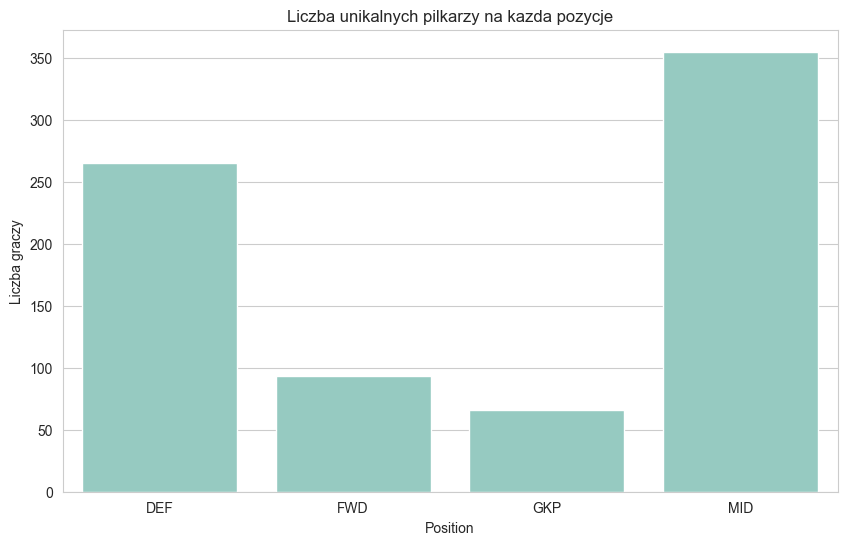

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(data.groupby("position")["web_name"].nunique())
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [15]:
[c for c in data.columns if "points" in c]

['total_points', 'event_points']

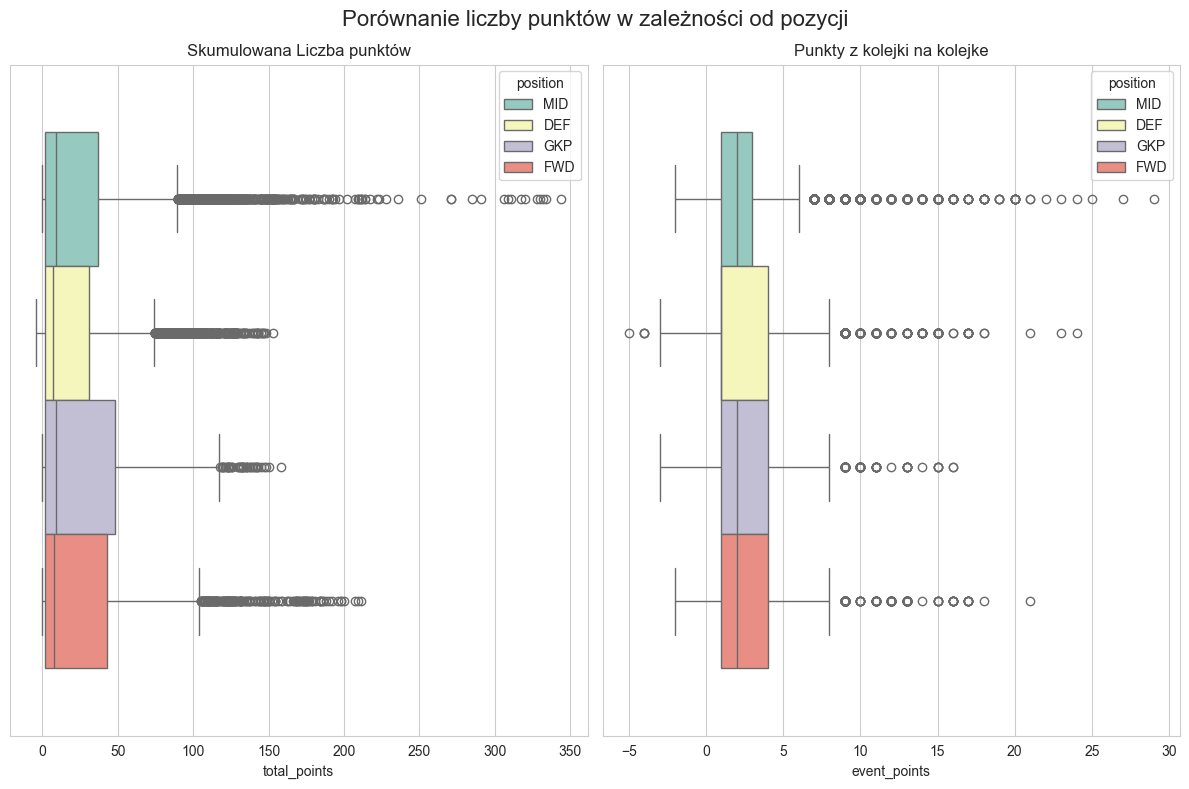

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

sns.boxplot(data=data, x="total_points", hue="position", ax=ax[0])
sns.boxplot(data=data, x="event_points", hue="position", ax=ax[1])

ax[0].set_title("Skumulowana Liczba punktów")
ax[1].set_title("Punkty z kolejki na kolejke")
fig.suptitle("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


Text(0.5, 1.0, 'Rozkład Total Points')

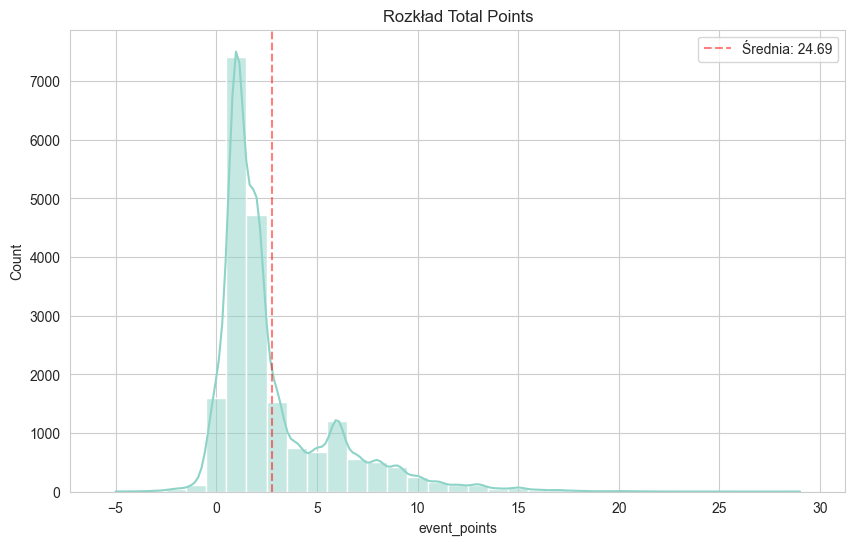

In [17]:
plt.figure(figsize=(10,6))

ax = sns.histplot(data.event_points,
             kde=True,
             discrete=True,
             bins=30)
ax.axvline(data.event_points.mean(), linestyle="--", color="r", alpha=0.5, label=f"Średnia: {data.total_points.mean():.2f}")
plt.legend(loc="upper right")
plt.title("Rozkład Total Points")

<Axes: >

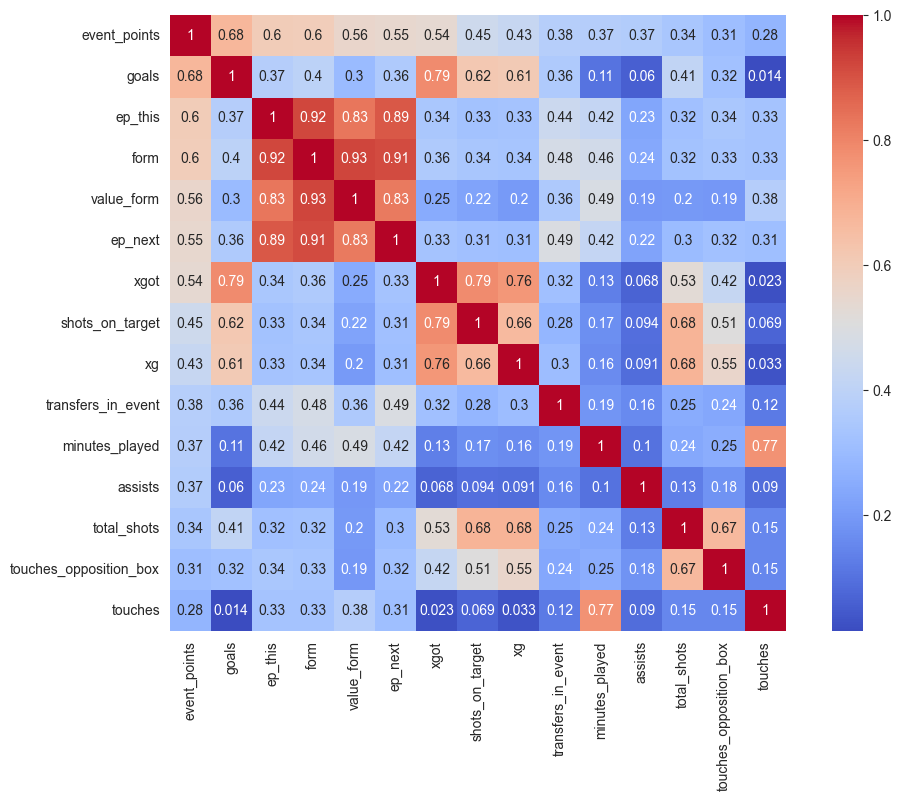

In [18]:
corr = data.select_dtypes(exclude=["object", "string"]).corr().apply(np.abs)
cols = corr["event_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)

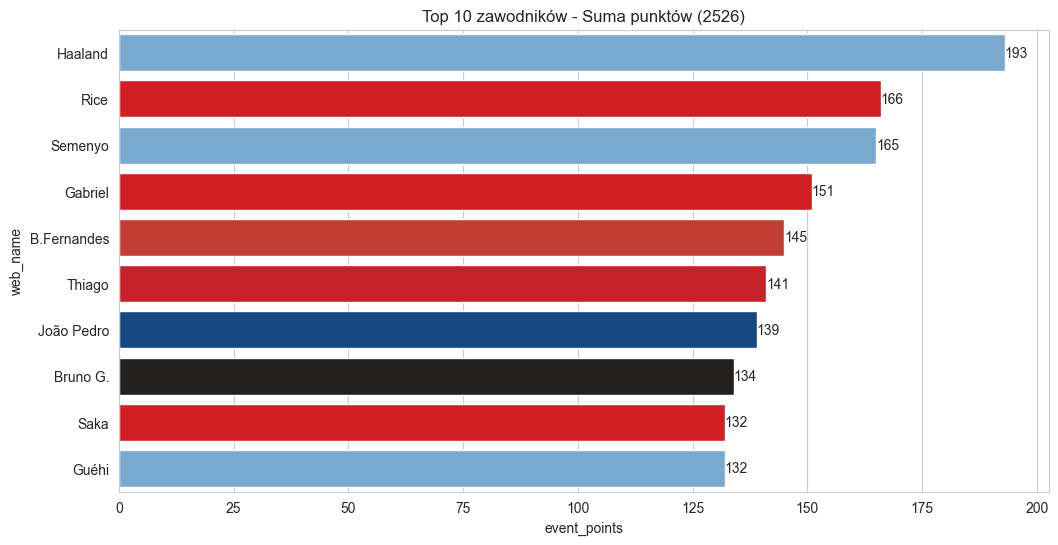

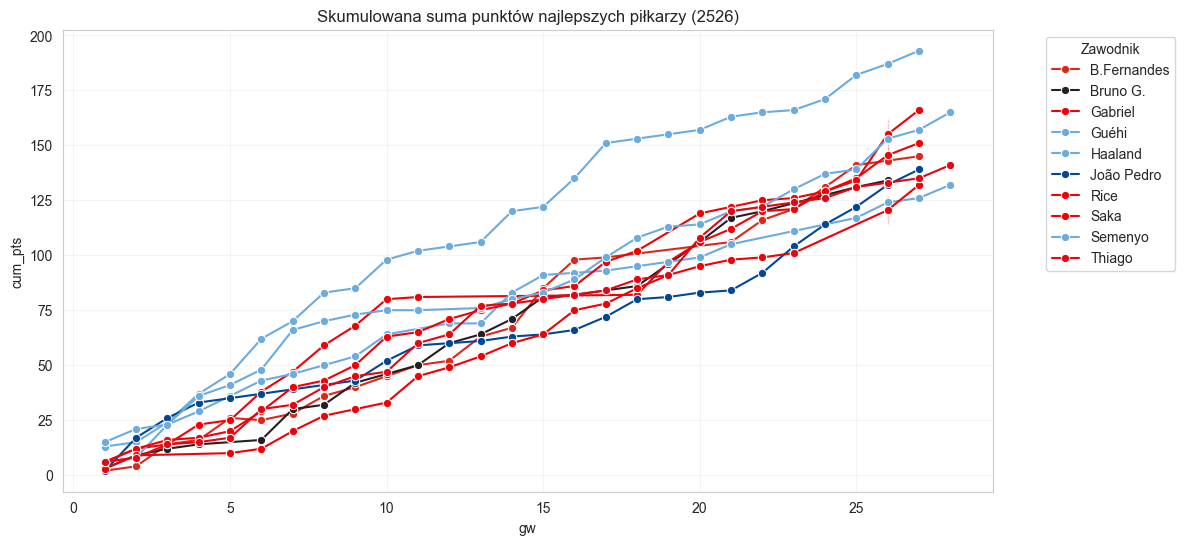

In [19]:
best_players_plots(df=data,
                   num_players=10,
                   season=2526)

In [20]:
data["value_ratio"] = (data.event_points / data.now_cost).fillna(0)


In [21]:
data[["web_name", "value_ratio", "position", "gw", "season_id"]].sort_values(by="value_ratio", ascending=False).head()

,web_name,value_ratio,position,gw,season_id
18505,Van de Ven,4.893617,DEF,9,2526
7032,Barnes,4.576271,MID,32,2425
19998,Schade,4.509804,MID,13,2425
13266,Lewis-Potter,4.375,DEF,17,2526
15129,J.Timber,4.363636,DEF,2,2526


In [22]:
x_cols = [c for c in data.columns if "expected" in c]

In [23]:
x_cols

['expected_assists',
 'expected_goals_conceded',
 'expected_goal_involvements',
 'expected_goals',
 'expected_goal_involvements_per_90',
 'expected_goals_conceded_per_90']

In [24]:
data.columns.to_list()

['position',
 'team_name',
 'match_id',
 'web_name',
 'second_name',
 'first_name',
 'status',
 'player_code',
 'touches_opposition_box',
 'gw',
 'team_code',
 'id',
 'selected_by_percent',
 'ep_this',
 'goals_conceded',
 'threat',
 'expected_assists',
 'fouls_committed',
 'now_cost',
 'xgot',
 'chances_created',
 'penalties_scored',
 'tackles_won',
 'value_season',
 'ict_index',
 'clearances',
 'accurate_passes_percent',
 'blocks',
 'successful_dribbles_percent',
 'xa',
 'creativity',
 'tackles_won_percent',
 'xgot_faced',
 'value_form',
 'selected_rank',
 'influence',
 'penalties_order',
 'successful_dribbles',
 'gk_accurate_long_balls',
 'transfers_in_event',
 'finish_min',
 'accurate_crosses',
 'interceptions',
 'tackles',
 'sweeper_actions',
 'aerial_duels_won_percent',
 'was_fouled',
 'corners_and_indirect_freekicks_order',
 'headed_clearances',
 'bonus',
 'total_points',
 'offsides',
 'duels_lost',
 'form',
 'event_points',
 'accurate_crosses_percent',
 'ground_duels_won',
 'gro

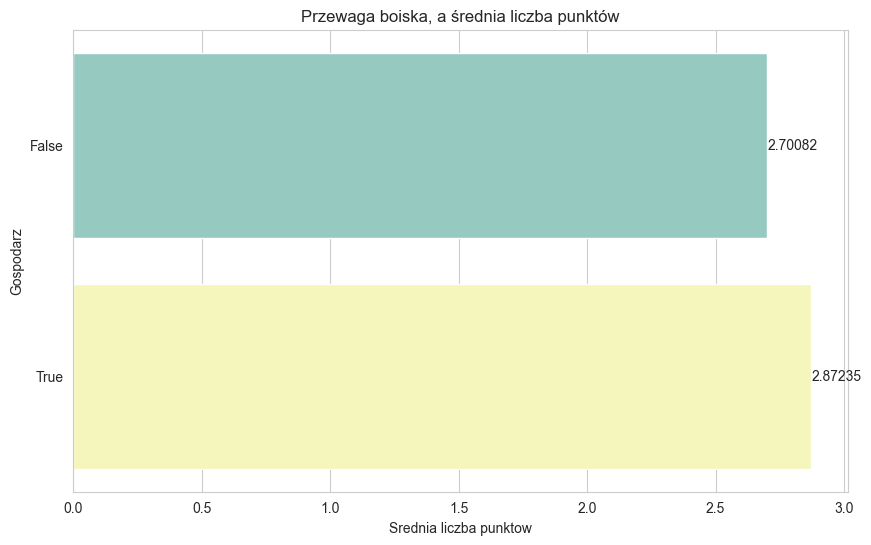

In [25]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="event_points",
    hue="was_home",
    estimator="mean",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

In [26]:
teams_avenue_form = data.groupby(["season_id", "team_name", "was_home"])["event_points"].mean().reset_index()
teams_avenue_form = teams_avenue_form.pivot(index=["season_id", "team_name"], columns="was_home", values="event_points")

# Zmień na 1 i 0 jeśli Twoje was_home to zera i jedynki
teams_avenue_form["home_advantage"] = teams_avenue_form[True] - teams_avenue_form[False]

# Zostawiamy nazwy drużyn i sezonu, zamieniając je z powrotem na zwykłe kolumny!
teams_avenue_form.reset_index(inplace=True)

teams_avenue_form.sort_values(by="home_advantage", ascending=False, inplace=True)
teams_avenue_form.columns.name = None

In [27]:
teams_avenue_form.head()

,season_id,team_name,False,True,home_advantage
37,2526,Sunderland,2.310185,3.374408,1.064222
33,2526,Man Utd,2.728507,3.522167,0.793661
24,2526,Brighton,2.314894,3.0625,0.747606
1,2425,Aston Villa,2.576052,3.314879,0.738827
30,2526,Leeds,2.3,3.031111,0.731111


In [28]:
teams_avenue_form.tail()

,season_id,team_name,False,True,home_advantage
38,2526,West Ham,2.570175,2.331776,-0.2384
12,2425,Man City,3.426966,3.138298,-0.288668
18,2425,West Ham,2.541935,2.205298,-0.336637
28,2526,Everton,3.2,2.817757,-0.382243
36,2526,Spurs,3.28125,2.40553,-0.87572


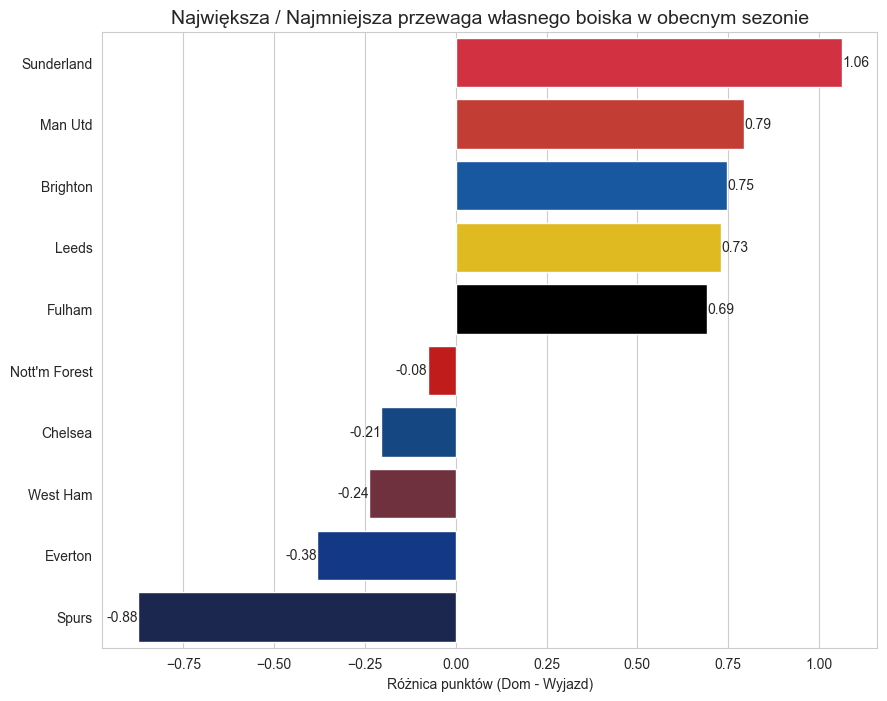

In [29]:
plt.figure(figsize=(10, 8))
ax =sns.barplot(data=pd.concat([teams_avenue_form[teams_avenue_form.season_id==2526].head(), teams_avenue_form[teams_avenue_form.season_id==2526].tail()], axis=0),
            x="home_advantage",
            hue="team_name",
            y="team_name",
            palette=colors_config.team_colors,
            errorbar=None)
plt.title("Największa / Najmniejsza przewaga własnego boiska w obecnym sezonie", fontsize=14)
plt.xlabel("Różnica punktów (Dom - Wyjazd)")
plt.ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")


In [30]:
team_names = [t for t in data[data.season_id==2526].team_name.unique()]
team_names

['Brighton',
 'Everton',
 'Newcastle',
 'Burnley',
 'Bournemouth',
 'Brentford',
 'Crystal Palace',
 'Leeds',
 "Nott'm Forest",
 'Man Utd',
 'Aston Villa',
 'West Ham',
 'Fulham',
 'Sunderland',
 'Wolves',
 'Man City',
 'Liverpool',
 'Chelsea',
 'Arsenal',
 'Spurs']

In [31]:
data[data.season_id==2526].gw.unique()

<IntegerArray>
[ 1,  3,  4,  5,  7,  8,  9, 16, 17, 19, 20, 21, 23, 24, 26, 27,  2,  6, 10,
 11, 12, 13, 14, 15, 18, 22, 25, 28]
Length: 28, dtype: Int64

In [32]:
data.to_parquet(config.TIDY_DATA_PATH)